# Load PCA Training and Testing Data

In [28]:

# ============================================================
# CELL 1: KNN CLASSIFICATION - IMPORTS AND CONFIGURATION
# ============================================================
#
# Purpose:
#     Configure paths and import libraries required for the
#     complete PCA + KNN classification pipeline.
#
# IMPORTANT:
#     The number of PCA components is NOT hard-coded here.
#
#     The notebook will automatically detect however many
#     PCA feature columns are present in pca_train.csv and
#     pca_test.csv.
#
#     Therefore:
#
#         PCA = 5 components  → KNN uses 5 features
#         PCA = 50 components → KNN uses 50 features
#         PCA = 20 components → KNN uses 20 features
#
#     No KNN code needs to be changed when PCA dimensions
#     are changed.
# ============================================================


# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import joblib

from pathlib import Path

from sklearn.neighbors import KNeighborsClassifier

from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
    roc_auc_score
)

from sklearn.preprocessing import label_binarize

import matplotlib.pyplot as plt


# ============================================================
# 2. PATH CONFIGURATION
# ============================================================

FEATURE_DIR = Path(
    r"C:\Users\harsh\OneDrive\Documents\BE_Major_Project\DATASET\Features(1)"
)


MODEL_DIR = Path(
    r"C:\Users\harsh\OneDrive\Documents\BE_Major_Project\MODELS"
)


# Create model directory if it does not exist

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# 3. PCA DATASET FILES
# ============================================================

PCA_TRAIN_FILE = (
    FEATURE_DIR /
    "pca_train.csv"
)


PCA_TEST_FILE = (
    FEATURE_DIR /
    "pca_test.csv"
)


# ============================================================
# 4. MODEL OUTPUT FILE
# ============================================================
#
# Use a new filename so the old KNN model trained on 5 PCA
# features is not accidentally loaded.
# ============================================================

KNN_MODEL_FILE = (
    MODEL_DIR /
    "pca_knn_glcm_dynamic.joblib"
)


# ============================================================
# 5. DISPLAY CONFIGURATION
# ============================================================

print("=" * 70)
print("PCA + KNN CLASSIFICATION")
print("=" * 70)


print(
    "\nPCA training file:"
)

print(
    PCA_TRAIN_FILE
)


print(
    "\nPCA testing file:"
)

print(
    PCA_TEST_FILE
)


print(
    "\nKNN model output:"
)

print(
    KNN_MODEL_FILE
)


print("\n" + "=" * 70)
print("CELL 1 COMPLETE")
print("=" * 70)

print(
    "\n✓ Libraries imported"
)

print(
    "✓ Dataset paths configured"
)

print(
    "✓ Model directory configured"
)

print(
    "✓ Dynamic PCA feature handling enabled"
)

print(
    "\nReady to load PCA data."
)



PCA + KNN CLASSIFICATION

PCA training file:
C:\Users\harsh\OneDrive\Documents\BE_Major_Project\DATASET\Features(1)\pca_train.csv

PCA testing file:
C:\Users\harsh\OneDrive\Documents\BE_Major_Project\DATASET\Features(1)\pca_test.csv

KNN model output:
C:\Users\harsh\OneDrive\Documents\BE_Major_Project\MODELS\pca_knn_glcm_dynamic.joblib

CELL 1 COMPLETE

✓ Libraries imported
✓ Dataset paths configured
✓ Model directory configured
✓ Dynamic PCA feature handling enabled

Ready to load PCA data.


# Separate Features and Class Labels

In [29]:

# ============================================================
# CELL 2: DYNAMIC PCA FEATURES AND CLASS LABELS
# ============================================================
#
# Dataset structure:
#
#     PC1
#     PC2
#     ...
#     PCN
#     class
#     filename
#
# The notebook automatically detects all PCA columns
# beginning with "PC".
#
# Therefore, the number of PCA components does NOT need
# to be hard-coded.
#
# Examples:
#
#     PC1 ... PC5   → 5 features
#     PC1 ... PC50  → 50 features
#     PC1 ... PC20  → 20 features
#
# IMPORTANT:
# PCA has already been applied in the Feature Extraction
# notebook. We do NOT perform PCA again here.
# ============================================================


# ============================================================
# 1. DETECT PCA FEATURE COLUMNS AUTOMATICALLY
# ============================================================

PCA_FEATURES = [
    column
    for column in train_df.columns
    if column.startswith("PC")
]


# ============================================================
# 2. VERIFY PCA FEATURES WERE FOUND
# ============================================================

if len(PCA_FEATURES) == 0:

    raise ValueError(
        "No PCA feature columns found. "
        "Expected columns such as PC1, PC2, PC3, ..."
    )


# ============================================================
# 3. VERIFY TEST DATA HAS THE SAME PCA FEATURES
# ============================================================

missing_test_columns = [
    column
    for column in PCA_FEATURES
    if column not in test_df.columns
]


if len(missing_test_columns) > 0:

    raise ValueError(
        f"Missing PCA columns in testing data: "
        f"{missing_test_columns}"
    )


# Check that test data does not have a different set
# of PCA columns

test_pca_features = [
    column
    for column in test_df.columns
    if column.startswith("PC")
]


if PCA_FEATURES != test_pca_features:

    raise ValueError(
        "Training and testing PCA feature columns do not match."
    )


# ============================================================
# 4. CREATE TRAINING FEATURES
# ============================================================

X_train = train_df[
    PCA_FEATURES
].values


# ============================================================
# 5. CREATE TRAINING LABELS
# ============================================================

y_train = train_df[
    "class"
].values


# ============================================================
# 6. CREATE TESTING FEATURES
# ============================================================

X_test = test_df[
    PCA_FEATURES
].values


# ============================================================
# 7. CREATE TESTING LABELS
# ============================================================

y_test = test_df[
    "class"
].values


# ============================================================
# 8. CONVERT FEATURES TO FLOAT32
# ============================================================

X_train = X_train.astype(
    np.float32
)

X_test = X_test.astype(
    np.float32
)


# ============================================================
# 9. DISPLAY FEATURE / LABEL INFORMATION
# ============================================================

print("=" * 70)
print("DYNAMIC PCA FEATURE / LABEL SEPARATION")
print("=" * 70)


print(
    "\nDetected PCA components:",
    len(PCA_FEATURES)
)


print(
    "\nPCA feature columns:"
)

print(
    PCA_FEATURES
)


print(
    "\nTraining feature shape:",
    X_train.shape
)


print(
    "Training label shape  :",
    y_train.shape
)


print(
    "\nTesting feature shape :",
    X_test.shape
)


print(
    "Testing label shape   :",
    y_test.shape
)


# ============================================================
# 10. DISPLAY CLASS LABELS
# ============================================================

print(
    "\nTraining classes:",
    np.unique(y_train)
)


print(
    "Testing classes :",
    np.unique(y_test)
)


# ============================================================
# 11. VERIFY NO NaN / INFINITE VALUES
# ============================================================

if not np.isfinite(
    X_train
).all():

    raise ValueError(
        "NaN or infinite values found in training features."
    )


if not np.isfinite(
    X_test
).all():

    raise ValueError(
        "NaN or infinite values found in testing features."
    )


# ============================================================
# 12. FINAL VERIFICATION
# ============================================================

print("\n" + "=" * 70)
print("FEATURE DATA VERIFICATION")
print("=" * 70)


print(
    "\n✓ PCA features detected automatically"
)

print(
    f"✓ Number of PCA features: {len(PCA_FEATURES)}"
)

print(
    "✓ Training/testing PCA columns match"
)

print(
    "✓ Training and testing shapes verified"
)

print(
    "✓ No NaN or infinite values found"
)

print(
    "\nFEATURE DATA READY FOR KNN"
)

print("=" * 70)


DYNAMIC PCA FEATURE / LABEL SEPARATION

Detected PCA components: 50

PCA feature columns:
['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'PC10', 'PC11', 'PC12', 'PC13', 'PC14', 'PC15', 'PC16', 'PC17', 'PC18', 'PC19', 'PC20', 'PC21', 'PC22', 'PC23', 'PC24', 'PC25', 'PC26', 'PC27', 'PC28', 'PC29', 'PC30', 'PC31', 'PC32', 'PC33', 'PC34', 'PC35', 'PC36', 'PC37', 'PC38', 'PC39', 'PC40', 'PC41', 'PC42', 'PC43', 'PC44', 'PC45', 'PC46', 'PC47', 'PC48', 'PC49', 'PC50']

Training feature shape: (3883, 50)
Training label shape  : (3883,)

Testing feature shape : (830, 50)
Testing label shape   : (830,)

Training classes: ['glioma' 'meningioma' 'pituitary']
Testing classes : ['glioma' 'meningioma' 'pituitary']

FEATURE DATA VERIFICATION

✓ PCA features detected automatically
✓ Number of PCA features: 50
✓ Training/testing PCA columns match
✓ Training and testing shapes verified
✓ No NaN or infinite values found

FEATURE DATA READY FOR KNN


# KNN Baseline Model

In [30]:

# ============================================================
# CELL 3: KNN BASELINE MODEL
# ============================================================
#
# Input:
#     X_train → Dynamically detected PCA features
#     y_train → Training class labels
#
# Model:
#     K-Nearest Neighbors (KNN)
#
# Purpose:
#     Establish a baseline KNN performance before
#     hyperparameter optimization.
#
# IMPORTANT:
# - PCA has already been performed.
# - The number of PCA features is detected automatically.
# - No additional PCA is performed here.
# - No additional feature scaling is performed here.
# - Test data is used ONLY for baseline evaluation.
# ============================================================


# ============================================================
# 1. CREATE BASELINE KNN MODEL
# ============================================================

knn_baseline = KNeighborsClassifier(
    n_neighbors=5
)


# ============================================================
# 2. TRAIN KNN
# ============================================================

knn_baseline.fit(
    X_train,
    y_train
)


# ============================================================
# 3. PREDICT TEST DATA
# ============================================================

y_pred_baseline = knn_baseline.predict(
    X_test
)


# ============================================================
# 4. CALCULATE BASELINE ACCURACY
# ============================================================

baseline_accuracy = accuracy_score(
    y_test,
    y_pred_baseline
)


# ============================================================
# 5. DISPLAY RESULT
# ============================================================

print("=" * 70)
print("KNN BASELINE RESULTS")
print("=" * 70)


print(
    f"\nNumber of PCA features: "
    f"{X_train.shape[1]}"
)


print(
    f"Number of neighbors (K): "
    f"{knn_baseline.n_neighbors}"
)


print(
    f"Baseline Accuracy       : "
    f"{baseline_accuracy * 100:.2f}%"
)


KNN BASELINE RESULTS

Number of PCA features: 50
Number of neighbors (K): 5
Baseline Accuracy       : 71.93%


# KNN Hyperparameter Tuning

In [32]:

# ============================================================
# CELL 4: FAST KNN HYPERPARAMETER TUNING
# ============================================================
#
# Purpose:
#     Automatically find the best KNN configuration using
#     ONLY the training dataset.
#
# Hyperparameters:
#     n_neighbors
#     weights
#     metric
#
# IMPORTANT:
# - PCA feature count is completely dynamic.
# - X_train and y_train are used for tuning.
# - X_test and y_test are NOT used during tuning.
# - 3-fold CV is used to reduce training time.
# - p is NOT included because Euclidean and Manhattan
#   distances are already explicitly specified.
# ============================================================


# ============================================================
# 1. CREATE BASE KNN MODEL
# ============================================================

knn = KNeighborsClassifier()


# ============================================================
# 2. DEFINE SMALL PARAMETER GRID
# ============================================================
#
# n_neighbors:
#     Number of neighbors used for prediction.
#
# weights:
#     uniform  → all neighbors have equal importance.
#     distance → closer neighbors have greater importance.
#
# metric:
#     euclidean → Euclidean distance.
#     manhattan → Manhattan distance.
#
# Total combinations:
#
#     3 K values
#     × 2 weighting methods
#     × 2 distance metrics
#     = 12 combinations
#
# With 3-fold CV:
#
#     12 × 3 = 36 model fits
# ============================================================

param_grid = {

    "n_neighbors": [
        3,
        5,
        7
    ],

    "weights": [
        "uniform",
        "distance"
    ],

    "metric": [
        "euclidean",
        "manhattan"
    ]
}


# ============================================================
# 3. COUNT PARAMETER COMBINATIONS
# ============================================================

from sklearn.model_selection import ParameterGrid

number_of_combinations = len(
    list(
        ParameterGrid(param_grid)
    )
)


# ============================================================
# 4. STRATIFIED CROSS-VALIDATION
# ============================================================
#
# StratifiedKFold preserves the class distribution in
# every validation fold.
# ============================================================

cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)


# ============================================================
# 5. DISPLAY SEARCH INFORMATION
# ============================================================

print("=" * 70)
print("FAST KNN HYPERPARAMETER TUNING")
print("=" * 70)


print(
    "\nPCA features:",
    X_train.shape[1]
)


print(
    "Training samples:",
    X_train.shape[0]
)


print(
    "\nNumber of parameter combinations:",
    number_of_combinations
)


print(
    "Cross-validation folds:",
    cv.n_splits
)


print(
    "Total model fits:",
    number_of_combinations * cv.n_splits
)


print(
    "\nOnly X_train and y_train are being used."
)


print(
    "X_test and y_test are NOT used."
)


# ============================================================
# 6. CREATE GRID SEARCH
# ============================================================
#
# scoring="accuracy":
#     Selects the configuration with the highest
#     cross-validation accuracy.
#
# n_jobs=-1:
#     Uses all available CPU cores.
# ============================================================

grid_search = GridSearchCV(

    estimator=knn,

    param_grid=param_grid,

    cv=cv,

    scoring="accuracy",

    n_jobs=-1,

    verbose=1,

    return_train_score=False
)


# ============================================================
# 7. RUN HYPERPARAMETER SEARCH
# ============================================================

print("\n" + "=" * 70)
print("STARTING KNN HYPERPARAMETER SEARCH")
print("=" * 70)


grid_search.fit(
    X_train,
    y_train
)


# ============================================================
# 8. DISPLAY BEST PARAMETERS
# ============================================================

print("\n" + "=" * 70)
print("BEST KNN PARAMETERS")
print("=" * 70)


print(
    "\nBest Parameters:"
)


print(
    grid_search.best_params_
)


# ============================================================
# 9. DISPLAY BEST CV ACCURACY
# ============================================================

print(
    "\nBest Cross-Validation Accuracy:"
)


print(
    f"{grid_search.best_score_ * 100:.2f}%"
)


# ============================================================
# 10. GET BEST KNN MODEL
# ============================================================

best_knn = (
    grid_search.best_estimator_
)


print(
    "\nBest KNN model:"
)


print(
    best_knn
)


# ============================================================
# 11. TUNING COMPLETE
# ============================================================

print("\n" + "=" * 70)
print("KNN HYPERPARAMETER TUNING COMPLETE")
print("=" * 70)


print(
    "\nBest Parameters:",
    grid_search.best_params_
)


print(
    "Best CV Accuracy:",
    f"{grid_search.best_score_ * 100:.2f}%"
)


print(
    "\nThese parameters will be used to train the"
)


print(
    "final KNN model in the next cell."
)



FAST KNN HYPERPARAMETER TUNING

PCA features: 50
Training samples: 3883

Number of parameter combinations: 12
Cross-validation folds: 3
Total model fits: 36

Only X_train and y_train are being used.
X_test and y_test are NOT used.

STARTING KNN HYPERPARAMETER SEARCH
Fitting 3 folds for each of 12 candidates, totalling 36 fits

BEST KNN PARAMETERS

Best Parameters:
{'metric': 'manhattan', 'n_neighbors': 7, 'weights': 'distance'}

Best Cross-Validation Accuracy:
75.02%

Best KNN model:
KNeighborsClassifier(metric='manhattan', n_neighbors=7, weights='distance')

KNN HYPERPARAMETER TUNING COMPLETE

Best Parameters: {'metric': 'manhattan', 'n_neighbors': 7, 'weights': 'distance'}
Best CV Accuracy: 75.02%

These parameters will be used to train the
final KNN model in the next cell.


C:\Users\harsh\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:1135: UserWarning: One or more of the test scores are non-finite: [0.69224994 0.70564252 0.69791554 0.71491231 0.69894315 0.71053233
        nan 0.74478446        nan 0.74246687        nan 0.75019385]
  warnings.warn(


# Knn model save

In [34]:

# ============================================================
# CELL 5: SAVE FINAL PCA + KNN MODEL
# ============================================================
#
# Purpose:
#     Save the best KNN model obtained from hyperparameter
#     tuning.
#
# IMPORTANT:
# - best_knn comes from GridSearchCV.
# - The model is trained using the current PCA feature set.
# - The number of PCA features is dynamic.
# - Test data is NOT evaluated in this cell.
# - Test evaluation will be performed after loading the
#   saved model in the next cells.
# ============================================================


# ============================================================
# 1. MODEL FILE PATH
# ============================================================

MODEL_FILE = (
    MODEL_DIR /
    "pca_knn_glcm_final.joblib"
)


# ============================================================
# 2. SAVE BEST KNN MODEL
# ============================================================

joblib.dump(
    best_knn,
    MODEL_FILE
)


# ============================================================
# 3. DISPLAY SAVED MODEL INFORMATION
# ============================================================

print("=" * 70)
print("FINAL PCA + KNN MODEL SAVED")
print("=" * 70)


print(
    "\nModel path:"
)

print(
    MODEL_FILE
)


print(
    "\nModel configuration:"
)

print(
    "K               :",
    best_knn.n_neighbors
)

print(
    "Distance metric :",
    best_knn.metric
)

print(
    "Weighting       :",
    best_knn.weights
)


# ============================================================
# 4. DISPLAY PCA FEATURE COUNT
# ============================================================

print(
    "\nPCA features used:",
    X_train.shape[1]
)


# ============================================================
# 5. CONFIRM MODEL SAVE
# ============================================================

print(
    "\nModel saved successfully."
)


print("\n" + "=" * 70)
print("CELL 5 COMPLETE")
print("=" * 70)


print(
    "\nThe saved KNN model will be loaded in the next cell"
)


print(
    "for test prediction and probability prediction."
)



FINAL PCA + KNN MODEL SAVED

Model path:
C:\Users\harsh\OneDrive\Documents\BE_Major_Project\MODELS\pca_knn_glcm_final.joblib

Model configuration:
K               : 7
Distance metric : manhattan
Weighting       : distance

PCA features used: 50

Model saved successfully.

CELL 5 COMPLETE

The saved KNN model will be loaded in the next cell
for test prediction and probability prediction.


# Knn Testing

In [35]:

# ============================================================
# CELL 6: LOAD SAVED KNN + TEST PREDICTION
# ============================================================
#
# Purpose:
#     Load the final KNN model saved in the previous cell
#     and generate predictions on the unseen PCA test data.
#
# Outputs:
#     y_pred       → predicted class labels
#     y_proba      → probability for each class
#
# IMPORTANT:
# - The saved KNN model is used.
# - X_test is NOT used during model training.
# - PCA feature count is detected automatically.
# - No PCA or scaling is performed here.
# ============================================================


# ============================================================
# 1. LOAD SAVED KNN MODEL
# ============================================================

print("=" * 70)
print("LOADING SAVED KNN MODEL")
print("=" * 70)


knn_model = joblib.load(
    MODEL_FILE
)


print(
    "\nKNN model loaded successfully."
)


print(
    "\nModel:"
)

print(
    knn_model
)


# ============================================================
# 2. DISPLAY TEST DATA INFORMATION
# ============================================================

print("\n" + "=" * 70)
print("TEST DATA")
print("=" * 70)


print(
    "\nTest samples:",
    X_test.shape[0]
)


print(
    "PCA features:",
    X_test.shape[1]
)


print(
    "Classes:",
    knn_model.classes_
)


# ============================================================
# 3. VERIFY FEATURE COUNT
# ============================================================
#
# KNN remembers the number of features it was trained with.
# This prevents accidentally passing a different PCA dataset.
# ============================================================

if X_test.shape[1] != knn_model.n_features_in_:

    raise ValueError(
        f"Feature mismatch: "
        f"Test data has {X_test.shape[1]} features, "
        f"but the saved KNN expects "
        f"{knn_model.n_features_in_} features."
    )


print(
    "\nFeature count verified."
)


# ============================================================
# 4. GENERATE CLASS PREDICTIONS
# ============================================================

print("\n" + "=" * 70)
print("GENERATING CLASS PREDICTIONS")
print("=" * 70)


y_pred = knn_model.predict(
    X_test
)


print(
    "\nClass predictions generated."
)


print(
    "Prediction shape:",
    y_pred.shape
)


# ============================================================
# 5. GENERATE CLASS PROBABILITIES
# ============================================================
#
# predict_proba() returns the probability assigned to
# each class for every test sample.
#
# Example:
#
#     [0.10, 0.20, 0.70]
#
# means:
#
#     glioma     → 10%
#     meningioma → 20%
#     pituitary  → 70%
#
# The class order is stored in:
#
#     knn_model.classes_
# ============================================================

print("\n" + "=" * 70)
print("GENERATING CLASS PROBABILITIES")
print("=" * 70)


y_proba = knn_model.predict_proba(
    X_test
)


print(
    "\nClass probabilities generated."
)


print(
    "Probability shape:",
    y_proba.shape
)


# ============================================================
# 6. VERIFY PROBABILITY VALUES
# ============================================================

if not np.isfinite(
    y_proba
).all():

    raise ValueError(
        "Invalid probability values detected."
    )


if not np.allclose(
    y_proba.sum(axis=1),
    1.0
):

    raise ValueError(
        "Probability values do not sum to 1."
    )


print(
    "\nProbability values verified."
)


# ============================================================
# 7. DISPLAY SAMPLE PREDICTIONS
# ============================================================

print("\n" + "=" * 70)
print("SAMPLE PREDICTIONS")
print("=" * 70)


print(
    "\nFirst 10 actual labels:"
)

print(
    y_test[:10]
)


print(
    "\nFirst 10 predicted labels:"
)

print(
    y_pred[:10]
)


print(
    "\nFirst 10 probability predictions:"
)

print(
    y_proba[:10]
)


# ============================================================
# 8. DISPLAY PREDICTION CONFIDENCE
# ============================================================
#
# The highest class probability is used as the prediction
# confidence for each sample.
# ============================================================

prediction_confidence = (
    np.max(
        y_proba,
        axis=1
    )
)


print(
    "\nFirst 10 prediction confidences:"
)

print(
    prediction_confidence[:10]
)


# ============================================================
# 9. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("TEST PREDICTION COMPLETE")
print("=" * 70)


print(
    "\nTest samples:",
    X_test.shape[0]
)


print(
    "Number of PCA features:",
    X_test.shape[1]
)


print(
    "Number of classes:",
    len(knn_model.classes_)
)


print(
    "Prediction shape:",
    y_pred.shape
)


print(
    "Probability shape:",
    y_proba.shape
)


print(
    "\nClass order:"
)

print(
    knn_model.classes_
)


print(
    "\n✓ Saved KNN loaded"
)

print(
    "✓ Test predictions generated"
)

print(
    "✓ Test probabilities generated"
)

print(
    "✓ Probability values verified"
)

print(
    "\nReady for evaluation in the next cells."
)


LOADING SAVED KNN MODEL

KNN model loaded successfully.

Model:
KNeighborsClassifier(metric='manhattan', n_neighbors=7, weights='distance')

TEST DATA

Test samples: 830
PCA features: 50
Classes: ['glioma' 'meningioma' 'pituitary']

Feature count verified.

GENERATING CLASS PREDICTIONS

Class predictions generated.
Prediction shape: (830,)

GENERATING CLASS PROBABILITIES

Class probabilities generated.
Probability shape: (830, 3)

Probability values verified.

SAMPLE PREDICTIONS

First 10 actual labels:
['glioma' 'glioma' 'glioma' 'glioma' 'glioma' 'glioma' 'glioma' 'glioma'
 'glioma' 'glioma']

First 10 predicted labels:
['glioma' 'glioma' 'glioma' 'glioma' 'glioma' 'glioma' 'pituitary'
 'glioma' 'glioma' 'glioma']

First 10 probability predictions:
[[1.         0.         0.        ]
 [0.83139625 0.         0.16860375]
 [0.57082368 0.14145143 0.28772489]
 [1.         0.         0.        ]
 [0.7231262  0.1351512  0.1417226 ]
 [1.         0.         0.        ]
 [0.43465667 0.        

# Knn evaluation 

KNN FINAL EVALUATION

Classes: ['glioma', 'meningioma', 'pituitary']
Test samples: 830
PCA features: 50

OVERALL TEST METRICS

Accuracy  : 75.78%
Precision : 76.98%
Recall    : 75.78%
F1-Score  : 75.67%

CLASSIFICATION REPORT
              precision    recall  f1-score   support

      glioma       0.81      0.60      0.69       234
  meningioma       0.84      0.82      0.83       301
   pituitary       0.67      0.82      0.73       295

    accuracy                           0.76       830
   macro avg       0.77      0.75      0.75       830
weighted avg       0.77      0.76      0.76       830


CONFUSION MATRIX

Rows    = Actual
Columns = Predicted

Classes: ['glioma', 'meningioma', 'pituitary']

 [[141  15  78]
 [ 11 247  43]
 [ 22  32 241]]


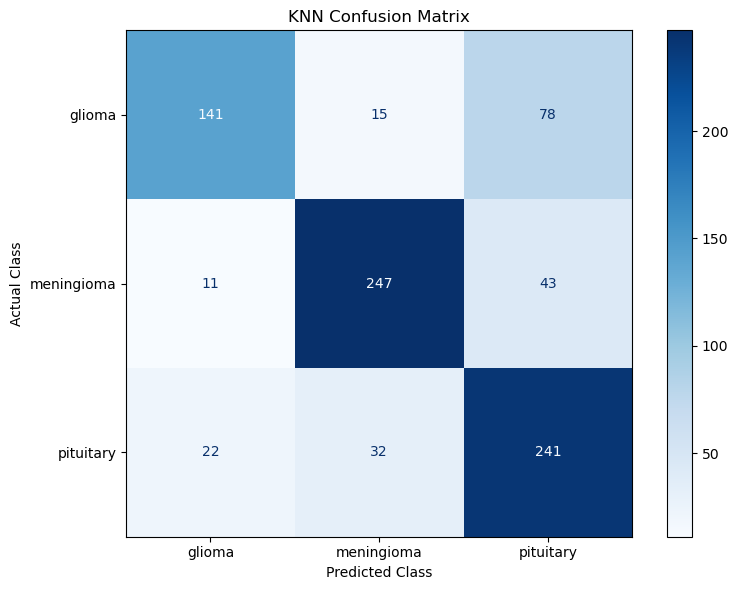


ROC / AUC RESULTS
glioma       AUC : 0.9046
meningioma   AUC : 0.9437
pituitary    AUC : 0.8836

Macro AUC    : 0.9107
Weighted AUC : 0.9113


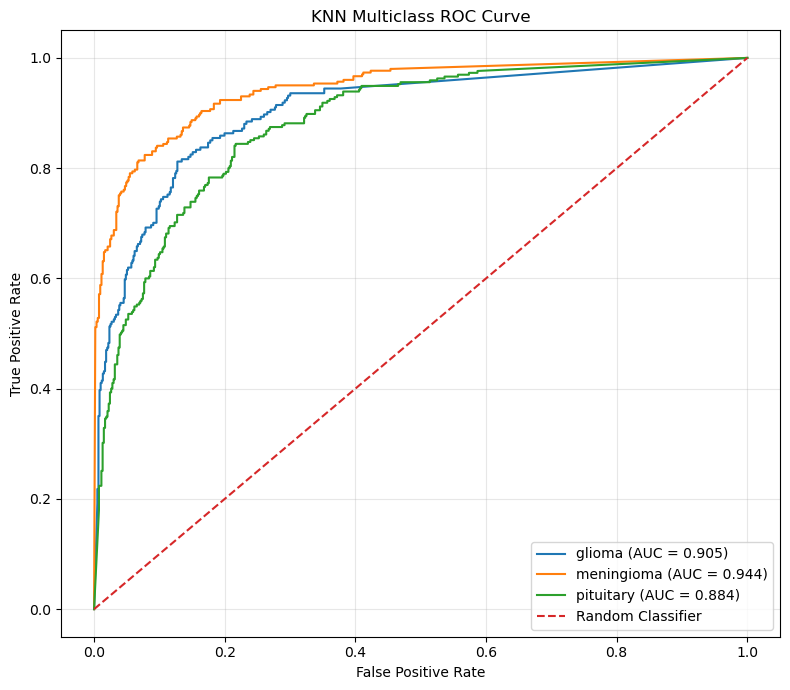


FINAL PCA + KNN SUMMARY

Model              : PCA + KNN
Test samples       : 830
PCA features       : 50
Accuracy           : 75.78%
Weighted Precision : 76.98%
Weighted Recall    : 75.78%
Weighted F1        : 75.67%
Macro AUC          : 0.9107
Weighted AUC       : 0.9113

EVALUATION COMPLETE


In [37]:
# ============================================================
# CELL 7: KNN FINAL EVALUATION
# CONFUSION MATRIX + ROC CURVE + AUC
# ============================================================
#
# Purpose:
#     Evaluate the KNN model on the unseen test dataset.
#
# Uses:
#     y_test      -> Actual test labels
#     y_pred      -> KNN predicted labels
#     y_proba     -> KNN class probabilities
#     knn_model   -> Trained / loaded KNN model
#
# Outputs:
#     Accuracy
#     Precision
#     Recall
#     F1-Score
#     Classification Report
#     Confusion Matrix
#     Multiclass ROC Curve
#     Per-class AUC
#     Macro AUC
#     Weighted AUC
#
# IMPORTANT:
# - PCA is NOT performed here.
# - Scaling is NOT performed here.
# - Test data is used only for final evaluation.
# - Number of PCA features is detected dynamically.
# ============================================================


# ============================================================
# 1. IMPORT REQUIRED LIBRARIES
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
    roc_auc_score
)

from sklearn.preprocessing import label_binarize


# ============================================================
# 2. VERIFY REQUIRED VARIABLES
# ============================================================

required_variables = [
    "y_test",
    "y_pred",
    "y_proba",
    "knn_model"
]


for variable in required_variables:

    if variable not in globals():

        raise NameError(
            f"'{variable}' is not available. "
            "Please run the previous cells first."
        )


# ============================================================
# 3. VERIFY PREDICTION SHAPES
# ============================================================

if len(y_test) != len(y_pred):

    raise ValueError(
        "Number of predictions does not match "
        "number of test samples."
    )


if len(y_test) != y_proba.shape[0]:

    raise ValueError(
        "Number of probability predictions does not "
        "match number of test samples."
    )


# ============================================================
# 4. GET CLASS ORDER FROM KNN MODEL
# ============================================================

knn_classes = knn_model.classes_


print("=" * 70)
print("KNN FINAL EVALUATION")
print("=" * 70)


print(
    "\nClasses:",
    list(knn_classes)
)


print(
    "Test samples:",
    len(y_test)
)


print(
    "PCA features:",
    X_test.shape[1]
)


# ============================================================
# 5. CALCULATE OVERALL METRICS
# ============================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)


precision = precision_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)


recall = recall_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)


f1 = f1_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)


# ============================================================
# 6. DISPLAY OVERALL RESULTS
# ============================================================

print("\n" + "=" * 70)
print("OVERALL TEST METRICS")
print("=" * 70)


print(
    f"\nAccuracy  : {accuracy * 100:.2f}%"
)


print(
    f"Precision : {precision * 100:.2f}%"
)


print(
    f"Recall    : {recall * 100:.2f}%"
)


print(
    f"F1-Score  : {f1 * 100:.2f}%"
)


# ============================================================
# 7. CLASSIFICATION REPORT
# ============================================================

print("\n" + "=" * 70)
print("CLASSIFICATION REPORT")
print("=" * 70)


print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)


# ============================================================
# 8. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=knn_classes
)


print("\n" + "=" * 70)
print("CONFUSION MATRIX")
print("=" * 70)


print(
    "\nRows    = Actual"
)


print(
    "Columns = Predicted"
)


print(
    "\nClasses:",
    list(knn_classes)
)


print(
    "\n",
    cm
)


# ============================================================
# 9. PLOT CONFUSION MATRIX
# ============================================================
#
# Same presentation style as the SVM confusion matrix:
#
#     - Blue color map
#     - Values displayed inside cells
#     - Actual Class on Y-axis
#     - Predicted Class on X-axis
#     - Colorbar showing sample count
# ============================================================

fig, ax = plt.subplots(
    figsize=(8, 6)
)


disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=knn_classes
)


disp.plot(
    ax=ax,
    values_format="d",
    cmap="Blues",
    colorbar=True
)


ax.set_title(
    "KNN Confusion Matrix"
)


ax.set_xlabel(
    "Predicted Class"
)


ax.set_ylabel(
    "Actual Class"
)


plt.tight_layout()

plt.show()


# ============================================================
# 10. BINARIZE TEST LABELS FOR ROC
# ============================================================
#
# Multiclass ROC uses One-vs-Rest:
#
#     glioma
#         vs
#     meningioma + pituitary
#
#     meningioma
#         vs
#     glioma + pituitary
#
#     pituitary
#         vs
#     glioma + meningioma
# ============================================================

y_test_binary = label_binarize(
    y_test,
    classes=knn_classes
)


# ============================================================
# 11. CALCULATE ROC CURVES
# ============================================================

fpr = {}
tpr = {}
roc_auc = {}


for i, class_name in enumerate(
    knn_classes
):

    fpr[i], tpr[i], _ = roc_curve(
        y_test_binary[:, i],
        y_proba[:, i]
    )


    roc_auc[i] = auc(
        fpr[i],
        tpr[i]
    )


# ============================================================
# 12. CALCULATE MACRO AND WEIGHTED AUC
# ============================================================

macro_auc = roc_auc_score(
    y_test,
    y_proba,
    multi_class="ovr",
    average="macro"
)


weighted_auc = roc_auc_score(
    y_test,
    y_proba,
    multi_class="ovr",
    average="weighted"
)


# ============================================================
# 13. DISPLAY AUC RESULTS
# ============================================================

print("\n" + "=" * 70)
print("ROC / AUC RESULTS")
print("=" * 70)


for i, class_name in enumerate(
    knn_classes
):

    print(
        f"{class_name:12s} AUC : "
        f"{roc_auc[i]:.4f}"
    )


print(
    f"\nMacro AUC    : {macro_auc:.4f}"
)


print(
    f"Weighted AUC : {weighted_auc:.4f}"
)


# ============================================================
# 14. PLOT MULTICLASS ROC CURVES
# ============================================================

fig, ax = plt.subplots(
    figsize=(8, 7)
)


for i, class_name in enumerate(
    knn_classes
):

    ax.plot(
        fpr[i],
        tpr[i],
        label=(
            f"{class_name} "
            f"(AUC = {roc_auc[i]:.3f})"
        )
    )


# ------------------------------------------------------------
# Random classifier reference line
# ------------------------------------------------------------

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)


# ------------------------------------------------------------
# Axis labels
# ------------------------------------------------------------

ax.set_xlabel(
    "False Positive Rate"
)


ax.set_ylabel(
    "True Positive Rate"
)


# ------------------------------------------------------------
# Title
# ------------------------------------------------------------

ax.set_title(
    "KNN Multiclass ROC Curve"
)


# ------------------------------------------------------------
# Legend
# ------------------------------------------------------------

ax.legend()


# ------------------------------------------------------------
# Grid
# ------------------------------------------------------------

ax.grid(
    True,
    alpha=0.3
)


plt.tight_layout()

plt.show()


# ============================================================
# 15. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("FINAL PCA + KNN SUMMARY")
print("=" * 70)


print(
    "\nModel              : PCA + KNN"
)


print(
    "Test samples       :",
    len(y_test)
)


print(
    "PCA features       :",
    X_test.shape[1]
)


print(
    f"Accuracy           : "
    f"{accuracy * 100:.2f}%"
)


print(
    f"Weighted Precision : "
    f"{precision * 100:.2f}%"
)


print(
    f"Weighted Recall    : "
    f"{recall * 100:.2f}%"
)


print(
    f"Weighted F1        : "
    f"{f1 * 100:.2f}%"
)


print(
    f"Macro AUC          : "
    f"{macro_auc:.4f}"
)


print(
    f"Weighted AUC       : "
    f"{weighted_auc:.4f}"
)


print("\n" + "=" * 70)
print("EVALUATION COMPLETE")
print("=" * 70)